# Chicago Crime Analytics

In [3]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, roc_auc_score
from sklearn.cluster import KMeans, MiniBatchKMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

sns.set(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 6)

data_path = os.path.join('data', 'raw', 'Crimes_-_2001_to_Present_20260601.csv')
print('Dataset exists:', os.path.exists(data_path))

# Load a limited number of rows first if the dataset is very large
sample_rows = 1000000
df = pd.read_csv(data_path, parse_dates=['Date', 'Updated On'], nrows=sample_rows, low_memory=False)
df = df[df['Date'].dt.year.between(2023, 2026)].copy()
print('Loaded rows after filtering to 2023-2026:', df.shape[0])
print('Columns:', df.columns.tolist())
df.head()

Dataset exists: True


C:\Users\DELL\AppData\Local\Temp\ipykernel_20580\3542072466.py:24: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = pd.read_csv(data_path, parse_dates=['Date', 'Updated On'], nrows=sample_rows, low_memory=False)
C:\Users\DELL\AppData\Local\Temp\ipykernel_20580\3542072466.py:24: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = pd.read_csv(data_path, parse_dates=['Date', 'Updated On'], nrows=sample_rows, low_memory=False)


Loaded rows after filtering to 2023-2026: 845288
Columns: ['ID', 'Case Number', 'Date', 'Block', 'IUCR', 'Primary Type', 'Description', 'Location Description', 'Arrest', 'Domestic', 'Beat', 'District', 'Ward', 'Community Area', 'FBI Code', 'X Coordinate', 'Y Coordinate', 'Year', 'Updated On', 'Latitude', 'Longitude', 'Location']


,ID,Case Number,Date,Block,IUCR,Primary Type,Description,Location Description,Arrest,Domestic,...,Ward,Community Area,FBI Code,X Coordinate,Y Coordinate,Year,Updated On,Latitude,Longitude,Location
0,14207207,JK266854,2026-05-23,0000X S HALSTED ST,0820,THEFT,$500 AND UNDER,GROCERY FOOD STORE,False,False,...,34.0,28.0,06,1171058.0,1900047.0,2026,2026-05-30 15:44:16,41.881203,-87.647342,"(41.881203182, -87.647342333)"
1,14208329,JK268216,2026-05-23,003XX S JEFFERSON ST,0910,MOTOR VEHICLE THEFT,AUTOMOBILE,STREET,False,False,...,34.0,28.0,07,1172381.0,1898742.0,2026,2026-05-30 15:44:16,41.877593,-87.642523,"(41.877593054, -87.64252296)"
2,14207858,JK267728,2026-05-23,002XX E HURON ST,0281,CRIMINAL SEXUAL ASSAULT,NON-AGGRAVATED,HOSPITAL BUILDING / GROUNDS,False,False,...,2.0,8.0,02,1178046.0,1905133.0,2026,2026-05-30 15:44:16,41.895003,-87.621528,"(41.895003278, -87.62152816)"
3,14206273,JK265732,2026-05-23,022XX N LOCKWOOD AVE,0520,ASSAULT,AGGRAVATED - KNIFE / CUTTING INSTRUMENT,RESIDENCE,False,True,...,36.0,19.0,04A,1140688.0,1914283.0,2026,2026-05-30 15:44:16,41.920880,-87.758510,"(41.920880436, -87.758509976)"
4,14208004,JK267751,2026-05-23,003XX E 68TH ST,1566,SEX OFFENSE,INDECENT SOLICITATION OF AN ADULT,OTHER (SPECIFY),False,False,...,6.0,69.0,17,1179334.0,1859992.0,2026,2026-05-30 15:44:16,41.771104,-87.618178,"(41.771103624, -87.618177987)"


## 2. Data Cleaning and Feature Engineering


In [4]:
# Basic cleaning
df = df.drop_duplicates()
df = df.dropna(subset=['Date', 'Primary Type', 'Description', 'Location Description'])

# Convert boolean-like flags to binary
for col in ['Arrest', 'Domestic']:
    if df[col].dtype == object:
        df[col] = df[col].map({'true': 1, 'false': 0, 'True': 1, 'False': 0})
    df[col] = df[col].astype(int)

# Time-based features
df['Hour'] = df['Date'].dt.hour
df['DayOfWeek'] = df['Date'].dt.day_name()
df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year
df['IsWeekend'] = df['DayOfWeek'].isin(['Saturday', 'Sunday']).astype(int)
df['Shift'] = pd.cut(df['Hour'], bins=[-1, 5, 11, 17, 21, 24], labels=['Late Night', 'Morning', 'Afternoon', 'Evening', 'Night']).astype(str)

# Reduce cardinality of text columns by taking top categories and grouping rare values
def keep_top_categories(series, top_n=20, other_label='OTHER'):
    top = series.value_counts().nlargest(top_n).index
    return series.where(series.isin(top), other_label)

for cat in ['Primary Type', 'Description', 'Location Description', 'Ward', 'Community Area', 'District', 'Beat', 'FBI Code']:
    if cat in df.columns:
        df[cat] = keep_top_categories(df[cat].astype(str), top_n=30, other_label='OTHER')

# Create a smaller working dataset for modeling
model_cols = ['Primary Type', 'Description', 'Location Description', 'Domestic', 'Beat', 'District', 'Ward', 'Community Area', 'FBI Code', 'Hour', 'DayOfWeek', 'Month', 'IsWeekend', 'Shift', 'Arrest']
df_model = df[model_cols].copy()

# Encode categorical features using label encoding for tree-based models and one-hot for linear models
label_encoders = {}
for col in ['Primary Type', 'Description', 'Location Description', 'Beat', 'District', 'Ward', 'Community Area', 'FBI Code', 'DayOfWeek', 'Shift']:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col].astype(str))
    label_encoders[col] = le

# Split train and validation sets
X = df_model.drop(columns=['Arrest'])
y = df_model['Arrest']
X_train, X_val, y_train, y_val = train_test_split(X, y, train_size=0.9, random_state=42, stratify=y)
print('Training size:', X_train.shape)
print('Validation size:', X_val.shape)
df_model.head()

Training size: (756972, 14)
Validation size: (84109, 14)


,Primary Type,Description,Location Description,Domestic,Beat,District,Ward,Community Area,FBI Code,Hour,DayOfWeek,Month,IsWeekend,Shift,Arrest
0,29,0,13,0,8,3,17,9,7,0,2,5,1,2,0
1,16,6,29,0,30,0,17,9,8,0,2,5,1,2,0
2,6,16,14,0,12,8,7,29,2,0,2,5,1,2,0
3,1,2,20,1,30,14,18,1,4,0,2,5,1,2,0
4,27,16,17,0,30,15,26,26,19,0,2,5,1,2,0


Total incidents: 995149
Arrest rate: 0.1367654491940403
Primary Type
THEFT                         227923
BATTERY                       173871
CRIMINAL DAMAGE               112178
MOTOR VEHICLE THEFT            91378
ASSAULT                        88624
OTHER OFFENSE                  64129
DECEPTIVE PRACTICE             59660
BURGLARY                       35512
ROBBERY                        33484
WEAPONS VIOLATION              29092
NARCOTICS                      24063
CRIMINAL TRESPASS              19703
OFFENSE INVOLVING CHILDREN      6733
CRIMINAL SEXUAL ASSAULT         6565
SEX OFFENSE                     5226
Name: count, dtype: int64


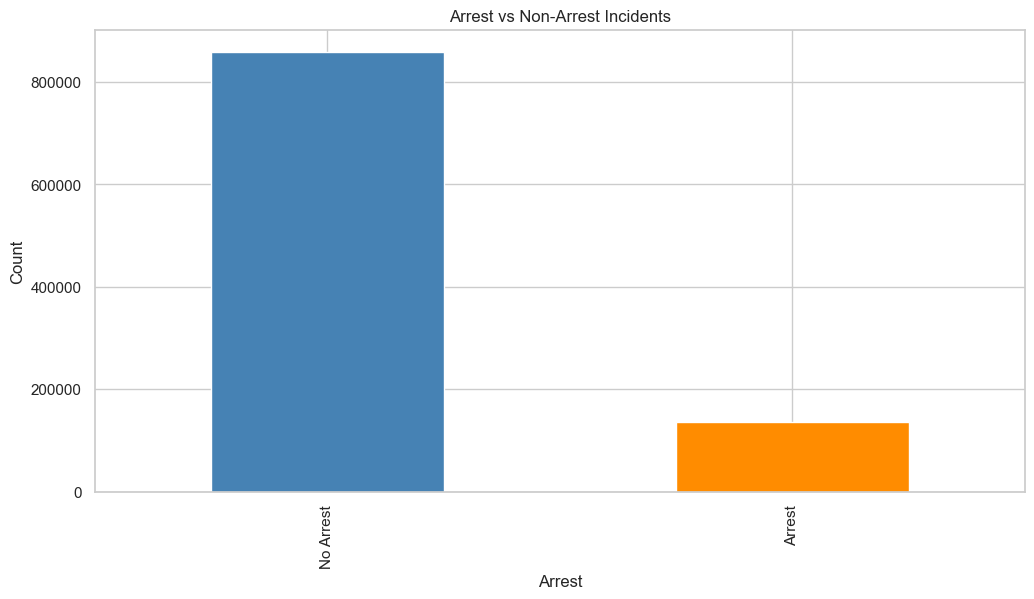

,Arrest Rate,Count
Primary Type,,
THEFT,0.065456,227923
BATTERY,0.170609,173871
CRIMINAL DAMAGE,0.036977,112178
MOTOR VEHICLE THEFT,0.029372,91378
ASSAULT,0.110884,88624
OTHER OFFENSE,0.177626,64129
DECEPTIVE PRACTICE,0.034076,59660
BURGLARY,0.050321,35512
ROBBERY,0.074095,33484


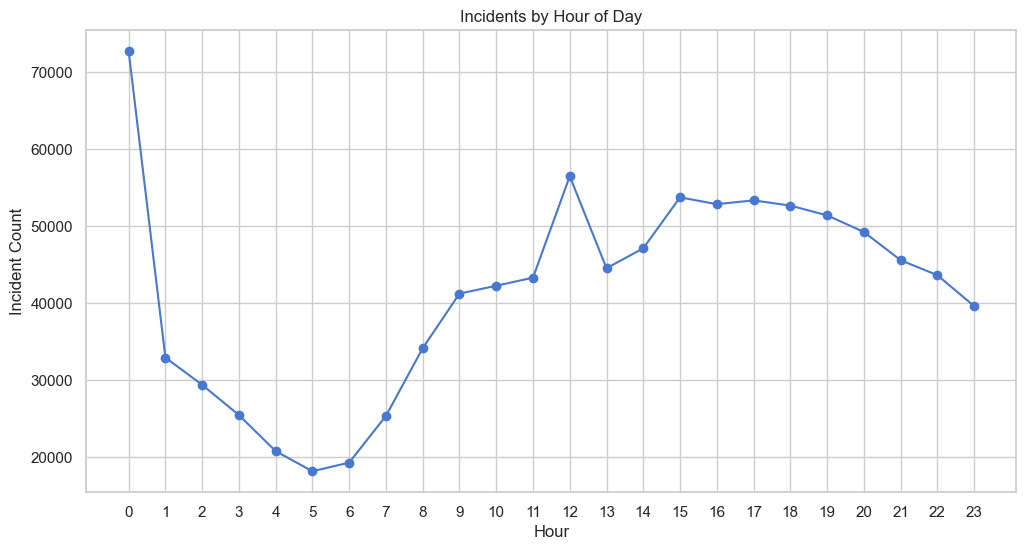

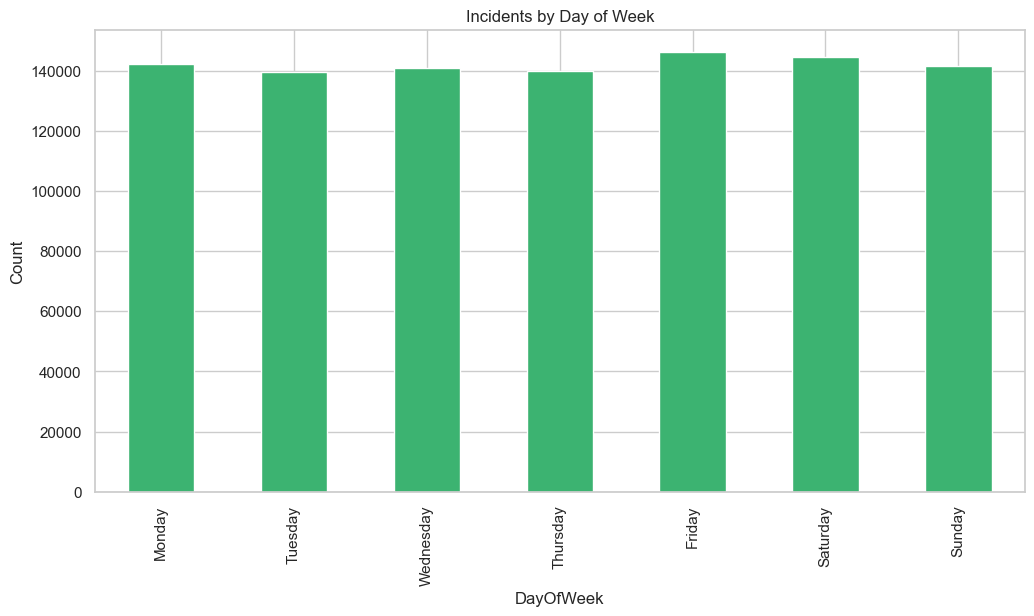

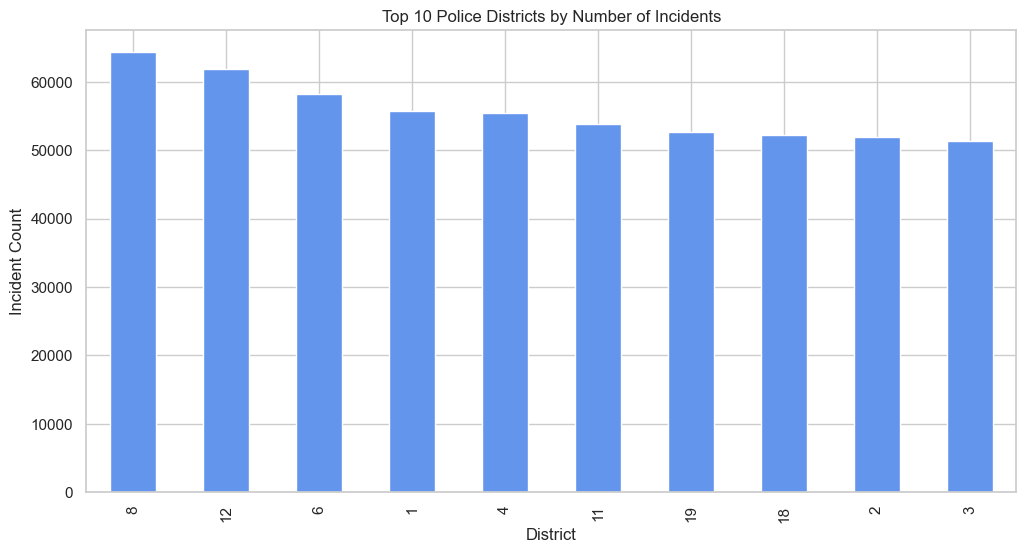

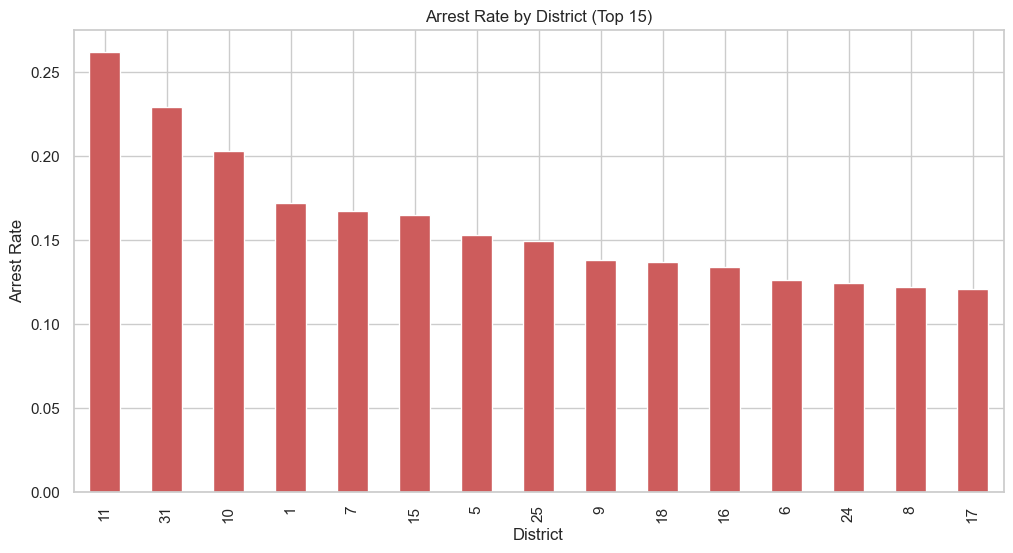

In [4]:
# Incident counts and distributions
print('Total incidents:', len(df))
print('Arrest rate:', df['Arrest'].mean())
print(df['Primary Type'].value_counts().head(15))

# Arrest vs non-arrest count
arrest_counts = df['Arrest'].value_counts().rename({0: 'No Arrest', 1: 'Arrest'})
arrest_counts.plot(kind='bar', color=['steelblue', 'darkorange'])
plt.title('Arrest vs Non-Arrest Incidents')
plt.ylabel('Count')
plt.show()

# Top crime types with arrest rate
top_crime = df.groupby('Primary Type').agg({'Arrest': ['mean', 'count']}).sort_values(('Arrest', 'count'), ascending=False).head(15)
top_crime.columns = ['Arrest Rate', 'Count']
display(top_crime)

# Temporal trends
hourly = df.groupby('Hour')['ID'].count()
hourly.plot(kind='line', marker='o')
plt.title('Incidents by Hour of Day')
plt.xlabel('Hour')
plt.ylabel('Incident Count')
plt.xticks(range(0, 24))
plt.show()

weekday = df['DayOfWeek'].value_counts().reindex(['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])
weekday.plot(kind='bar', color='mediumseagreen')
plt.title('Incidents by Day of Week')
plt.ylabel('Count')
plt.show()

# Area summaries
top_districts = df['District'].value_counts().head(10)
top_districts.plot(kind='bar', color='cornflowerblue')
plt.title('Top 10 Police Districts by Number of Incidents')
plt.ylabel('Incident Count')
plt.show()

# Arrest rate by district matrix
district_arrest = df.groupby('District')['Arrest'].mean().sort_values(ascending=False).head(15)
district_arrest.plot(kind='bar', color='indianred')
plt.title('Arrest Rate by District (Top 15)')
plt.ylabel('Arrest Rate')
plt.show()

## 4. Classification Model Training


In [5]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=200, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42, max_depth=8),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100, max_depth=12)
}
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    accuracy = accuracy_score(y_val, y_pred)
    precision = precision_score(y_val, y_pred, zero_division=0)
    recall = recall_score(y_val, y_pred, zero_division=0)
    f1 = f1_score(y_val, y_pred, zero_division=0)
    results.append({'Model': name, 'Accuracy': accuracy, 'Precision': precision, 'Recall': recall, 'F1 Score': f1})
    print(f'--- {name} ---')
    print(classification_report(y_val, y_pred, zero_division=0))

results_df = pd.DataFrame(results).sort_values('F1 Score', ascending=False)
results_df

--- Logistic Regression ---
              precision    recall  f1-score   support

           0       0.86      1.00      0.93     85905
           1       0.34      0.01      0.02     13610

    accuracy                           0.86     99515
   macro avg       0.60      0.50      0.47     99515
weighted avg       0.79      0.86      0.80     99515

--- Decision Tree ---
              precision    recall  f1-score   support

           0       0.91      0.99      0.95     85905
           1       0.87      0.41      0.56     13610

    accuracy                           0.91     99515
   macro avg       0.89      0.70      0.76     99515
weighted avg       0.91      0.91      0.90     99515

--- Random Forest ---
              precision    recall  f1-score   support

           0       0.91      0.99      0.95     85905
           1       0.89      0.39      0.54     13610

    accuracy                           0.91     99515
   macro avg       0.90      0.69      0.75     99515
we

,Model,Accuracy,Precision,Recall,F1 Score
1,Decision Tree,0.911169,0.867149,0.413887,0.560330
2,Random Forest,0.910405,0.892738,0.391991,0.544777
0,Logistic Regression,0.862151,0.338323,0.008303,0.016208


## 5. Clustering Analysis

In [10]:
from sklearn.decomposition import PCA
from sklearn.cluster import MiniBatchKMeans

# Optimized clustering: sample, scale, reduce, then cluster with MiniBatchKMeans
cluster_features = ['Primary Type', 'Description', 'Location Description', 'Domestic', 'Beat', 'District', 'Ward', 'Community Area', 'FBI Code', 'Hour', 'IsWeekend']

# Sample a manageable subset for clustering to avoid long runtimes
sample_size = min(50000, len(df_model))
if len(df_model) > sample_size:
    X_cluster_sample = df_model[cluster_features].sample(n=sample_size, random_state=42)
else:
    X_cluster_sample = df_model[cluster_features].copy()

# Scale features (important when mixing encoded categorical numeric codes)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster_sample)

# Reduce dimensionality with PCA while preserving most variance (fast downstream clustering)
try:
    pca = PCA(n_components=0.90, svd_solver='full')
    X_pca = pca.fit_transform(X_scaled)
    print('PCA reduced to components:', X_pca.shape[1])
except Exception:
    # Fallback to a small fixed number of components
    pca = PCA(n_components=min(10, X_scaled.shape[1]))
    X_pca = pca.fit_transform(X_scaled)
    print('PCA fallback components:', X_pca.shape[1])

# Use MiniBatchKMeans for performance on larger samples
mbk = MiniBatchKMeans(n_clusters=6, random_state=42, batch_size=1000, n_init=3)
cluster_labels = mbk.fit_predict(X_pca)

# Evaluate clustering on the reduced sample
silhouette = silhouette_score(X_pca, cluster_labels)
print('MiniBatchKMeans silhouette score (sampled):', silhouette)

# Attach cluster labels back to the sampled frame and summarize
df_clusters = X_cluster_sample.copy()
df_clusters['Cluster'] = cluster_labels

# Join with Arrest/Domestic from original df using index alignment
summary = df[['Arrest', 'Domestic']].join(df_clusters['Cluster']).groupby('Cluster').agg({'Arrest': 'mean', 'Domestic': 'mean', 'Cluster': 'count'})
summary = summary.rename(columns={'Cluster': 'Count'})
display(summary)

# Inspect cluster modes using original encoded features
for cluster in sorted(df_clusters['Cluster'].unique()):
    print(f'Cluster {cluster} top mode values:')
    idx = df_clusters[df_clusters['Cluster'] == cluster].index
    profile = df_model.loc[idx, cluster_features].mode().iloc[0]
    display(profile.to_frame(name=f'Cluster {cluster} mode'))

PCA reduced to components: 9
MiniBatchKMeans silhouette score (sampled): 0.1056893300655947


,Arrest,Domestic,Count
Cluster,,,
0.0,0.214475,0.157999,6038
1.0,0.144236,0.982501,7772
2.0,0.052890,0.015318,10380
3.0,0.125444,0.022932,7326
4.0,0.141732,0.036175,8763
5.0,0.169221,0.021808,9721


Cluster 0 top mode values:


,Cluster 0 mode
Primary Type,22
Description,16
Location Description,1
Domestic,0
Beat,30
District,6
Ward,30
Community Area,30
FBI Code,25
Hour,0


Cluster 1 top mode values:


...

,Cluster 3 mode
Primary Type,5
Description,20
Location Description,29
Domestic,0
Beat,30
District,21
Ward,30
Community Area,30
FBI Code,16
Hour,15


Cluster 4 top mode values:


,Cluster 4 mode
Primary Type,29
Description,16
Location Description,29
Domestic,0
Beat,30
District,8
Ward,30
Community Area,30
FBI Code,7
Hour,0


Cluster 5 top mode values:


,Cluster 5 mode
Primary Type,29
Description,16
Location Description,29
Domestic,0
Beat,30
District,3
Ward,13
Community Area,13
FBI Code,7
Hour,15


## 6. Simulated Streaming with Kafka and Flink

In [11]:
# This section demonstrates a simulated streaming workflow without requiring a full Kafka/Flink cluster.
# If Kafka and Flink are installed, the code below can be adapted to a real event pipeline.

sample_stream = df.sort_values('Date').head(2000).copy()
sample_stream['EventTime'] = sample_stream['Date']

# Simulate a producer that emits one row at a time
def stream_events(dataframe):
    for _, row in dataframe.iterrows():
        yield {
            'ID': row['ID'],
            'Date': row['Date'],
            'Primary Type': row['Primary Type'],
            'Location Description': row['Location Description'],
            'District': row['District'],
            'Arrest': row['Arrest'],
            'Domestic': row['Domestic']
        }

# Process events in simulated time windows
windowed_summary = []
window_size = pd.Timedelta('1H')
start_time = sample_stream['EventTime'].min()
end_time = sample_stream['EventTime'].max()
current_start = start_time

while current_start <= end_time:
    current_end = current_start + window_size
    window_data = sample_stream[(sample_stream['EventTime'] >= current_start) & (sample_stream['EventTime'] < current_end)]
    windowed_summary.append({
        'window_start': current_start,
        'incident_count': len(window_data),
        'arrests': window_data['Arrest'].sum(),
        'domestic': window_data['Domestic'].sum()
    })
    current_start = current_end

stream_summary = pd.DataFrame(windowed_summary)
stream_summary.head()

C:\Users\DELL\AppData\Local\Temp\ipykernel_6284\1079143765.py:22: Pandas4Warning: 'H' is deprecated and will be removed in a future version. Please use 'h' instead of 'H'.
  window_size = pd.Timedelta('1H')


,window_start,incident_count,arrests,domestic
0,2022-05-28 14:30:00,31,3,5
1,2022-05-28 15:30:00,25,6,3
2,2022-05-28 16:30:00,31,7,3
3,2022-05-28 17:30:00,37,8,7
4,2022-05-28 18:30:00,36,11,3


## 7. Model Evaluation and Reporting

              Model Accuracy Precision Recall F1 Score
      Decision Tree    0.911     0.867  0.414    0.560
      Random Forest    0.910     0.893  0.392    0.545
Logistic Regression    0.862     0.338  0.008    0.016


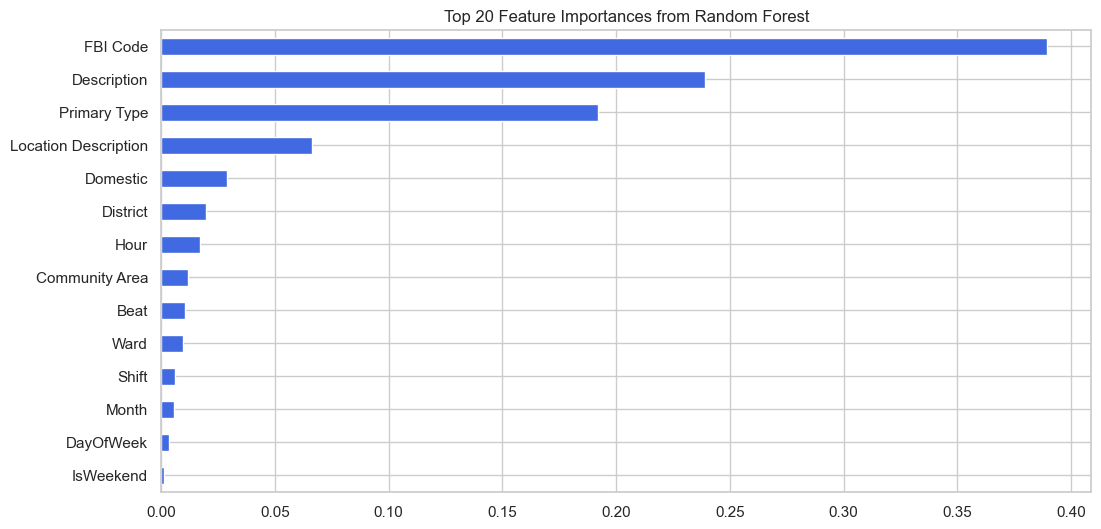

Cluster summary:


,Arrest,Domestic,Count
Cluster,,,
0.0,0.214475,0.157999,6038
1.0,0.144236,0.982501,7772
2.0,0.052890,0.015318,10380
3.0,0.125444,0.022932,7326
4.0,0.141732,0.036175,8763
5.0,0.169221,0.021808,9721


Simulated streaming summary head:
         window_start  incident_count  arrests  domestic
0 2022-05-28 14:30:00              31        3         5
1 2022-05-28 15:30:00              25        6         3
2 2022-05-28 16:30:00              31        7         3
3 2022-05-28 17:30:00              37        8         7
4 2022-05-28 18:30:00              36       11         3
Summary:
- The arrest prediction task highlights model performance and class imbalance.
- Clustering identifies groups that share crime type, location, and time characteristics.
- Simulated streaming sketch shows how event windows can be built from historical data.


In [14]:
# Compare classification performance
# Compare classification performance (avoid .style which requires jinja2)
formatted = results_df.copy()
for c in ['Accuracy', 'Precision', 'Recall', 'F1 Score']:
    formatted[c] = formatted[c].map(lambda x: f'{x:.3f}')
print(formatted.to_string(index=False))

# Feature importance from Random Forest
rf = models['Random Forest']
feature_importance = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False).head(20)
feature_importance.plot(kind='barh', color='royalblue')
plt.title('Top 20 Feature Importances from Random Forest')
plt.gca().invert_yaxis()
plt.show()

print('Cluster summary:')
display(summary)

print('Simulated streaming summary head:')
print(stream_summary.head())

print('Summary:')
print('- The arrest prediction task highlights model performance and class imbalance.')
print('- Clustering identifies groups that share crime type, location, and time characteristics.')
print('- Simulated streaming sketch shows how event windows can be built from historical data.')